In [3]:
!pip install --no-index --find-links /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages segmentation-models-pytorch albumentations omegaconf torchmetrics

Looking in links: /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages
Processing /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages/segmentation_models_pytorch-0.5.0-py3-none-any.whl


In [4]:
import os
from pathlib import Path

# 1. Thiết lập cấu hình và định nghĩa rõ các tập
INPUT_DIR = Path('/kaggle/input')

# Cấu hình chia sequence theo yêu cầu
SPLIT_CONFIG = {
    'train': ['seq1', 'seq3', 'seq4', 'seq5', 'seq8', 'seq9'],
    'val': ['seq2'],
    'test': ['seq6', 'seq7']
}

print("=== BẮT ĐẦU TÌM VÀ CHIA DATASET THEO SEQUENCE ===")

# Các list chứa đường dẫn ảnh cho từng tập
train_files = []
val_files = []
test_files = []

# 2. Duyệt qua thư mục và phân loại ảnh vào các tập tương ứng
found_sequences = set()

for dataset in INPUT_DIR.iterdir():
    if not dataset.is_dir(): continue
    
    # Tìm tất cả các thư mục có tên bắt đầu bằng 'seq' (hoặc chứa 'color')
    for seq_dir in dataset.rglob('*'):
        if seq_dir.is_dir() and (seq_dir / 'color').exists():
            seq_name = seq_dir.name
            found_sequences.add(seq_name)
            
            # Thu thập toàn bộ ảnh trong thư mục color của sequence này
            color_dir = seq_dir / 'color'
            images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
            
            # Phân loại vào đúng list dựa trên tên sequence
            if seq_name in SPLIT_CONFIG['train']:
                train_files.extend(images)
            elif seq_name in SPLIT_CONFIG['val']:
                val_files.extend(images)
            elif seq_name in SPLIT_CONFIG['test']:
                test_files.extend(images)
            else:
                print(f"[CẢNH BÁO] Tìm thấy thư mục '{seq_name}' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).")

# Kiểm tra xem có thiếu sequence nào không
expected_seqs = set(SPLIT_CONFIG['train'] + SPLIT_CONFIG['val'] + SPLIT_CONFIG['test'])
missing_seqs = expected_seqs - found_sequences
if missing_seqs:
    print(f"\n[LỖI CẢNH BÁO] Không tìm thấy các sequences sau trong /kaggle/input: {missing_seqs}")
    print("Vui lòng kiểm tra lại tên thư mục (có thể bị sai chữ hoa/thường, ví dụ 'Seq1' thay vì 'seq1').\n")

# Thêm chốt chặn lỗi:
total_images = len(train_files) + len(val_files) + len(test_files)
if total_images == 0:
    raise ValueError("Không tìm thấy ảnh nào! Hãy kiểm tra lại định dạng file hoặc cấu trúc thư mục.")

# 3. Hàm hỗ trợ để lấy danh sách mask tương ứng (Dùng khi training)
def get_mask_paths(image_paths):
    mask_paths = []
    for p in image_paths:
        # 1. Thử thay 'color' bằng 'label' hoặc 'labels' (các tên phổ biến)
        # và thử các đuôi file phổ biến (.png, .jpg)
        possible_mask_dirs = ['label', 'labels', 'semantic', 'masks']
        found = False
        
        for mask_dir_name in possible_mask_dirs:
            # Tạo đường dẫn thử nghiệm
            temp_path = Path(str(p).replace('/color/', f'/{mask_dir_name}/'))
            
            # Kiểm tra các đuôi file có thể có
            for ext in ['.png', '.jpg', '.jpeg']:
                test_path = temp_path.with_suffix(ext)
                if test_path.exists():
                    mask_paths.append(test_path)
                    found = True
                    break
            if found: break
            
        if not found:
            # Nếu vẫn không thấy, in ra để debug chính xác thư mục đó có gì
            parent_dir = p.parent.parent
            print(f"[CẢNH BÁO] Không tìm thấy mask cho: {p.name}")
            print(f"Thư mục sequence chứa các folder: {[d.name for d in parent_dir.iterdir() if d.is_dir()]}")
            mask_paths.append(None) # Đánh dấu lỗi
            
    return mask_paths

train_masks = get_mask_paths(train_files)
val_masks = get_mask_paths(val_files)
test_masks = get_mask_paths(test_files)

# 4. Hiển thị kết quả
print("-" * 50)
print(f"📊 KẾT QUẢ CHIA THEO SEQUENCE CỤ THỂ:")
print(f"✅ Tập TRAIN (seq1,3,4,5,8,9): {len(train_files)} ảnh")
print(f"✅ Tập VALID (seq2)          : {len(val_files)} ảnh")
print(f"✅ Tập TEST  (seq6,7)        : {len(test_files)} ảnh")
print(f"Tổng số ảnh thu thập được    : {total_images} ảnh")
print("-" * 50)

# Ví dụ kiểm tra file
if len(train_files) > 0:
    print(f"Ví dụ 1 file TRAIN: {train_files[0]}")
    print(f"Ví dụ mask TRAIN  : {train_masks[0]}")

=== BẮT ĐẦU TÌM VÀ CHIA DATASET THEO SEQUENCE ===
--------------------------------------------------
📊 KẾT QUẢ CHIA THEO SEQUENCE CỤ THỂ:
✅ Tập TRAIN (seq1,3,4,5,8,9): 8677 ảnh
✅ Tập VALID (seq2)          : 1501 ảnh
✅ Tập TEST  (seq6,7)        : 2873 ảnh
Tổng số ảnh thu thập được    : 13051 ảnh
--------------------------------------------------
Ví dụ 1 file TRAIN: /kaggle/input/datasets/khesng/uav-forest-sunny-next/seq8/seq8/color/001183.png
Ví dụ mask TRAIN  : /kaggle/input/datasets/khesng/uav-forest-sunny-next/seq8/seq8/labels/001183.png


In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

LABEL_COLORS = [
    (0, 255, 255),    # 0: Sky
    (0, 127, 0),      # 1: Deciduous_trees
    (19, 132, 69),    # 2: Coniferous_trees
    (0, 53, 65),      # 3: Fallen_trees
    (130, 76, 0),     # 4: Dirt_ground
    (152, 251, 152),  # 5: Ground_vegetation
    (151, 126, 171),  # 6: Rocks
    (250, 150, 0),    # 7: Building
    (115, 176, 195),  # 8: Fence
    (123, 123, 123),  # 9: Car
    (0, 0, 0),        # 10: Empty
]
CLASS_NAMES = [
    'Sky', 'Deciduous_trees', 'Coniferous_trees', 'Fallen_trees',
    'Dirt_ground', 'Ground_vegetation', 'Rocks', 'Building',
    'Fence', 'Car', 'Empty',
]
NUM_CLASSES = len(CLASS_NAMES)  # = 11
PALETTE = np.array(LABEL_COLORS, dtype=np.uint8)

RGB_TO_CLASS_LUT = np.full((256, 256, 256), NUM_CLASSES - 1, dtype=np.uint8)
for cid, color in enumerate(LABEL_COLORS):
    RGB_TO_CLASS_LUT[color[0], color[1], color[2]] = cid

def fast_rgb_to_mask(rgb_arr):
    return RGB_TO_CLASS_LUT[rgb_arr[..., 0], rgb_arr[..., 1], rgb_arr[..., 2]]

def class_id_to_rgb_fast(class_map):
    return PALETTE[class_map]

In [6]:
##### import os
import random
import multiprocessing
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Đổi seed ở đây mỗi lần chạy: 42 / 123 / 2025
SEED = 42
seed_everything(SEED)

MODEL_NAME      = 'unetpp'
ENCODER         = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
IMG_SIZE        = (1024, 1024)
BATCH_SIZE      = 4
EPOCHS          = 50
LR              = 1e-4
NUM_WORKERS     = 4
PATIENCE        = 15
SAVE_TOP_K      = 2
USE_AMP         = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[INFO] Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"[INFO] GPU: {torch.cuda.get_device_name()}")

[INFO] Device: cuda
[INFO] GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [7]:
import os
from pathlib import Path

IS_KAGGLE  = os.path.exists('/kaggle')
OUTPUT_DIR = Path('/kaggle/working/outputs') if IS_KAGGLE else Path('outputs')
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def upload_to_drive(path):
    pass

In [8]:
import torch

class CheckpointSaver:
    def __init__(self, dirpath, top_k=3, maximize=True):
        self.dirpath  = dirpath
        self.top_k    = top_k
        self.maximize = maximize
        self.saved_ckpts = []  # list of (score, filepath)

    def save_if_best(self, state_dict, epoch, current_score):
        filename = f"epoch_{epoch:03d}_miou_{current_score:.4f}.pth"
        filepath = os.path.join(self.dirpath, filename)

        self.saved_ckpts.append((current_score, filepath))
        self.saved_ckpts.sort(key=lambda x: x[0], reverse=self.maximize)

        top_k_paths = [ckpt[1] for ckpt in self.saved_ckpts[:self.top_k]]

        if filepath in top_k_paths:
            torch.save(state_dict, filepath)
            print(f'  * [TOP {self.top_k}] mIoU: {current_score:.4f} -> {filename}')
            upload_to_drive(filepath)

            # Xóa checkpoint ngoài top-k
            while len(self.saved_ckpts) > self.top_k:
                _, removed = self.saved_ckpts.pop()  # xóa phần tử tệ nhất
                if os.path.exists(removed):
                    os.remove(removed)
            return True
        else:
            # Không lọt top-k, chưa lưu file nên chỉ cần xóa khỏi list
            self.saved_ckpts = [c for c in self.saved_ckpts if c[1] != filepath]
            return False

In [9]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

INPUT_DIR = Path('/kaggle/input')
SPLIT_CONFIG = {
    'train': ['seq1', 'seq3', 'seq4', 'seq5', 'seq8', 'seq9'],
    'val':   ['seq2'],
    'test':  ['seq6', 'seq7']
}

def collect_data():
    data = {'train': [], 'val': [], 'test': []}
    for dataset_path in INPUT_DIR.iterdir():
        if not dataset_path.is_dir(): continue
        for color_dir in dataset_path.rglob('color'):
            seq_dir  = color_dir.parent
            seq_name = seq_dir.name
            # Tìm folder mask
            mask_dir = seq_dir / 'label'
            if not mask_dir.exists():
                mask_dir = seq_dir / 'labels'
            if not mask_dir.exists(): continue
            # Xác định tập
            target_set = None
            for key, seq_list in SPLIT_CONFIG.items():
                if seq_name in seq_list:
                    target_set = key
                    break
            if not target_set: continue
            # Ghép cặp ảnh - mask
            for img_p in sorted(list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))):
                mask_p = (mask_dir / img_p.name).with_suffix('.png')
                if not mask_p.exists():
                    mask_p = (mask_dir / img_p.name).with_suffix('.jpg')
                if mask_p.exists():
                    data[target_set].append((str(img_p), str(mask_p)))
    return data['train'], data['val'], data['test']

train_files, val_files, test_files = collect_data()
print(f"[INFO] Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("Không tìm thấy dữ liệu! Kiểm tra lại cấu trúc thư mục.")

class ForestDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path, mask_path = self.file_list[idx]
        img      = np.array(Image.open(img_path).convert('RGB'))
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask     = fast_rgb_to_mask(mask_rgb)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.long()

train_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, p=0.3, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_ds = ForestDataset(train_files, train_tf)
val_ds   = ForestDataset(val_files,   val_tf)

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
print(f'[OK] Dataloaders ready. Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


[INFO] Train: 8677 | Val: 1501 | Test: 2873
[OK] Dataloaders ready. Train: 2169 batches | Val: 376 batches


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [10]:
import shutil, glob
import torch.nn as nn
import segmentation_models_pytorch as smp

print("=== CHUẨN BỊ TRỌNG SỐ OFFLINE ===")
CACHE_DIR = '/root/.cache/torch/hub/checkpoints/'
os.makedirs(CACHE_DIR, exist_ok=True)

# ✅ Sửa path Kaggle dataset
WEIGHT_DIR = '/kaggle/input/datasets/itmeagain77/resnet50-pytorch-weights'
pth_files  = glob.glob(os.path.join(WEIGHT_DIR, '*.pth'))
if pth_files:
    cache_file = os.path.join(CACHE_DIR, 'resnet50-19c8e357.pth')
    if not os.path.exists(cache_file):
        shutil.copy(pth_files[0], cache_file)
        print(f"[OK] Đã copy: {os.path.basename(pth_files[0])} -> Cache")
    else:
        print("[OK] Trọng số đã có trong cache.")
else:
    print("[CẢNH BÁO] Không tìm thấy .pth offline, sẽ tải từ Internet.")

MODELS = {
    'unet':          lambda: smp.Unet(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'unetpp':        lambda: smp.UnetPlusPlus(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'deeplabv3plus': lambda: smp.DeepLabV3Plus(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'segformer':     lambda: smp.Segformer(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),  # ✅
}

if MODEL_NAME not in MODELS:
    raise ValueError(f"MODEL_NAME '{MODEL_NAME}' không hợp lệ. Chọn trong: {list(MODELS.keys())}")

model = MODELS[MODEL_NAME]().to(DEVICE)
print(f'🚀 MODEL: {MODEL_NAME} | Encoder: {ENCODER} | Classes: {NUM_CLASSES}')
print(f'📊 Params: {sum(p.numel() for p in model.parameters()):,}')

=== CHUẨN BỊ TRỌNG SỐ OFFLINE ===
[OK] Đã copy: resnet50-19c8e357.pth -> Cache


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/smp-hub/resnet50.imagenet/resolve/00cb74e366966d59cd9a35af57e618af9f88efe9/config.json
Retrying in 1s [Retry 1/5].
/usr/local/lib/python3.12/dist-packages/segmentation_models_pytorch/encoders/__init__.py:136: UserWarning: Error loading resnet50 `imagenet` weights from Hugging Face Hub, trying loading from original url...
  warnings.warn(message, UserWarning)


🚀 MODEL: unetpp | Encoder: resnet50 | Classes: 11
📊 Params: 48,987,195


In [11]:
from tqdm import tqdm

def compute_class_weights(file_list, num_classes, c=1.02):
    """
    Công thức từ bài báo gốc: w = 1 / ln(c + p_class)
    p_class = tỷ lệ pixel của class đó trong toàn bộ tập train
    """
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, mask_path in tqdm(file_list, desc='Computing class weights'):
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask = fast_rgb_to_mask(mask_rgb)
        for cid in range(num_classes):
            counts[cid] += (mask == cid).sum()
    total = counts.sum()
    freq  = counts / total
    w     = 1.0 / np.log(c + freq)
    w     = w / w.sum() * num_classes  # normalize
    print("\n📊 Class weights:")
    for i, (name, wi, fi) in enumerate(zip(CLASS_NAMES, w, freq)):
        print(f"  {name:<22} freq={fi*100:6.3f}%  weight={wi:.4f}")
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

class_weights = compute_class_weights(train_files, NUM_CLASSES)

Computing class weights: 100%|██████████| 8677/8677 [03:30<00:00, 41.21it/s]


📊 Class weights:
  Sky                    freq=14.325%  weight=0.2375
  Deciduous_trees        freq=16.435%  weight=0.2123
  Coniferous_trees       freq=29.036%  weight=0.1329
  Fallen_trees           freq= 0.577%  weight=1.4115
  Dirt_ground            freq= 2.003%  weight=0.9150
  Ground_vegetation      freq=35.456%  weight=0.1129
  Rocks                  freq= 1.914%  weight=0.9353
  Building               freq= 0.194%  weight=1.6549
  Fence                  freq= 0.013%  weight=1.8018
  Car                    freq= 0.047%  weight=1.7724
  Empty                  freq= 0.000%  weight=1.8135


In [12]:
class CEWithWeightsLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=class_weights,
            ignore_index=NUM_CLASSES - 1
        )

    def forward(self, logits, targets):
        loss = self.ce(logits, targets)
        return loss, {
            'focal': 0.0, 'dice': 0.0, 'ce': loss.item(),
            'w_focal': 0.0, 'w_dice': 0.0, 'w_ce': 1.0,
        }

    def get_weights(self):
        return {'w_focal': 0.0, 'w_dice': 0.0, 'w_ce': 1.0}

criterion = CEWithWeightsLoss(class_weights=None).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

In [11]:
import time, gc, csv

def get_miou(cm, n_ignore_last=1):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    valid_iou   = iou[:-n_ignore_last]
    valid_union = union[:-n_ignore_last]
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

best_val_miou = -float('inf')
no_improve    = 0
saver         = CheckpointSaver(dirpath=CKPT_DIR, top_k=SAVE_TOP_K, maximize=True)

# Header CSV: thêm các cột w_focal, w_dice, w_ce để theo dõi adaptive weights
LOG_FILE = OUTPUT_DIR / 'training_log.csv'
with open(LOG_FILE, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'epoch', 'train_loss', 'val_loss', 'miou',
        'w_focal', 'w_dice', 'w_ce',          # adaptive weights
        'l_focal', 'l_dice', 'l_ce',          # individual loss values
        *CLASS_NAMES[:-1]
    ])

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    criterion.train()
    train_loss = 0.0
    n_train    = 0
    # Tích lũy loss components để log trung bình mỗi epoch
    loss_components_sum = {'focal': 0, 'dice': 0, 'ce': 0,
                           'w_focal': 0, 'w_dice': 0, 'w_ce': 0}

    pbar_train = tqdm(train_loader, desc=f'E{epoch} [TRAIN]')
    for imgs, masks in pbar_train:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out              = model(imgs)
            loss, components = criterion(out, masks)  # trả về tuple

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_train    += 1
        for k in loss_components_sum:
            loss_components_sum[k] += components[k]

        pbar_train.set_postfix({
            'loss':    f'{loss.item():.4f}',
            'wF':      f'{components["w_focal"]:.2f}',
            'wD':      f'{components["w_dice"]:.2f}',
            'wCE':     f'{components["w_ce"]:.2f}',
        })

    # ── VAL ────────────────────────────────────────────────
    model.eval()
    criterion.eval()
    val_loss = 0.0
    n_val    = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    pbar_val = tqdm(val_loader, desc=f'E{epoch} [VAL]')
    with torch.no_grad():
        for imgs, masks in pbar_val:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out              = model(imgs)
                loss, _          = criterion(out, masks)
                val_loss        += loss.item()
                n_val           += 1
            preds = out.argmax(1)
            p = preds.detach().cpu().numpy().flatten()
            t = masks.detach().cpu().numpy().flatten()
            valid = (t >= 0) & (t < NUM_CLASSES)
            cm += np.bincount(
                t[valid] * NUM_CLASSES + p[valid],
                minlength=NUM_CLASSES ** 2
            ).reshape(NUM_CLASSES, NUM_CLASSES)

    # ── METRICS ────────────────────────────────────────────
    avg_train = train_loss / n_train
    avg_val   = val_loss   / n_val
    miou, class_ious = get_miou(cm)
    avg_components = {k: v / n_train for k, v in loss_components_sum.items()}
    scheduler.step()

    print(f'\n▶ Epoch {epoch:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | mIoU: {miou:.4f} | {time.time()-t0:.0f}s')
    print(f'   Adaptive weights → Focal: {avg_components["w_focal"]:.3f} | '
          f'Dice: {avg_components["w_dice"]:.3f} | CE: {avg_components["w_ce"]:.3f}')

    # Ghi log (thêm adaptive weights)
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch, avg_train, avg_val, miou,
            avg_components['w_focal'], avg_components['w_dice'], avg_components['w_ce'],
            avg_components['focal'],   avg_components['dice'],   avg_components['ce'],
            *[f'{class_ious[i]:.4f}' for i in range(NUM_CLASSES - 1)]
        ])

    # ── SAVE & EARLY STOPPING ──────────────────────────────
    checkpoint_dict = {
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'criterion_state_dict': criterion.state_dict(),  # lưu cả adaptive weights
        'optimizer_state_dict': optimizer.state_dict(),
        'miou':                 miou,
        'loss_weights':         criterion.get_weights(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'random_states': {
            'python':   random.getstate(),
            'numpy':    np.random.get_state(),
            'torch':    torch.get_rng_state(),
            'cuda':     torch.cuda.get_rng_state_all(),
        },
    }
    is_best = saver.save_if_best(state_dict=checkpoint_dict, epoch=epoch, current_score=miou)

    if is_best:
        best_val_miou = miou
        no_improve    = 0
        print(f"  ⭐ New best! Class-wise IoU:")
        for i, name in enumerate(CLASS_NAMES[:-1]):
            print(f"    - {name:<22}: {class_ious[i]:.4f}")
    else:
        no_improve += 1

    del cm
    gc.collect()
    torch.cuda.empty_cache()

    if no_improve >= PATIENCE:
        print(f'🛑 Early Stopping at Epoch {epoch}')
        break

print(f'\n✅ Training done! Best val mIoU: {best_val_miou:.4f}')
print(f'   Final adaptive weights: {criterion.get_weights()}')

E1 [VAL]: 100%|██████████| 376/376 [00:53<00:00,  7.03it/s]
/tmp/ipykernel_163/4192849017.py:6: RuntimeWarning: invalid value encountered in divide
  iou   = np.where(union > 0, inter / union, 0.0)



▶ Epoch 001 | Train: 0.4649 | Val: 0.3082 | mIoU: 0.4464 | 668s
   Adaptive weights → Focal: 0.000 | Dice: 0.000 | CE: 1.000
  * [TOP 2] mIoU: 0.4464 -> epoch_001_miou_0.4464.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7433
    - Coniferous_trees      : 0.7681
    - Fallen_trees          : 0.4928
    - Dirt_ground           : 0.8006
    - Ground_vegetation     : 0.8596
    - Rocks                 : 0.7995
    - Building              : 0.0000
    - Fence                 : 0.0000
    - Car                   : 0.0000


E2 [VAL]: 100%|██████████| 376/376 [00:52<00:00,  7.18it/s]



▶ Epoch 002 | Train: 0.2895 | Val: 0.2715 | mIoU: 0.5442 | 665s
   Adaptive weights → Focal: 0.000 | Dice: 0.000 | CE: 1.000
  * [TOP 2] mIoU: 0.5442 -> epoch_002_miou_0.5442.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7495
    - Coniferous_trees      : 0.7900
    - Fallen_trees          : 0.5205
    - Dirt_ground           : 0.8361
    - Ground_vegetation     : 0.8712
    - Rocks                 : 0.8226
    - Building              : 0.8519
    - Fence                 : 0.0000
    - Car                   : 0.0000


E3 [VAL]: 100%|██████████| 376/376 [00:52<00:00,  7.15it/s]


...


▶ Epoch 048 | Train: 0.1880 | Val: 0.2209 | mIoU: 0.7435 | 662s
   Adaptive weights → Focal: 0.000 | Dice: 0.000 | CE: 1.000
  * [TOP 2] mIoU: 0.7435 -> epoch_048_miou_0.7435.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7931
    - Coniferous_trees      : 0.8143
    - Fallen_trees          : 0.7123
    - Dirt_ground           : 0.8844
    - Ground_vegetation     : 0.8841
    - Rocks                 : 0.8129
    - Building              : 0.9306
    - Fence                 : 0.7397
    - Car                   : 0.8633


E49 [VAL]: 100%|██████████| 376/376 [00:53<00:00,  7.08it/s]



▶ Epoch 049 | Train: 0.1880 | Val: 0.2230 | mIoU: 0.7411 | 665s
   Adaptive weights → Focal: 0.000 | Dice: 0.000 | CE: 1.000


E50 [VAL]: 100%|██████████| 376/376 [00:49<00:00,  7.52it/s]



▶ Epoch 050 | Train: 0.1878 | Val: 0.2402 | mIoU: 0.7417 | 662s
   Adaptive weights → Focal: 0.000 | Dice: 0.000 | CE: 1.000

✅ Training done! Best val mIoU: 0.7435
   Final adaptive weights: {'w_focal': 0.0, 'w_dice': 0.0, 'w_ce': 1.0}


In [18]:
import shutil
from IPython.display import FileLink

checkpoint_folder = '/kaggle/working/outputs/checkpoints'
output_zip_name   = '/kaggle/working/my_forest_checkpoints'

if os.path.exists(checkpoint_folder):
    shutil.make_archive(output_zip_name, 'zip', checkpoint_folder)
    print(f"✅ Archived: {output_zip_name}.zip")
    display(FileLink('my_forest_checkpoints.zip'))
else:
    print(f"❌ Folder not found: {checkpoint_folder}")

✅ Archived: /kaggle/working/my_forest_checkpoints.zip


/kaggle/working/my_forest_checkpoints.zip

In [13]:
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def get_miou(cm, n_ignore_last=1):
    """Tính mIoU, bỏ qua n class cuối (mặc định bỏ class Empty)"""
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    valid_iou   = iou[:-n_ignore_last]
    valid_union = union[:-n_ignore_last]
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# 1. Load Checkpoint tốt nhất
BEST_CKPT = '/kaggle/input/datasets/wennni/checkpoint-e48-exp1/epoch_048_miou_0.7435.pth' 

if os.path.exists(BEST_CKPT):
    print(f"🔄 Đang nạp model tốt nhất từ: {BEST_CKPT}")
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Đã nạp thành công mIoU kỷ lục: {ckpt.get('miou', ckpt.get('metric', 0)):.4f}")
else:
    print("⚠️ Cảnh báo: Không tìm thấy file checkpoint. Đang dùng model hiện tại trong RAM.")

# 2. Khởi tạo Dataloader cho tập Test
test_ds = ForestDataset(test_files, val_tf) # Dùng val_tf (không augment)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 3. Vòng lặp Test
model.eval()
cm_test = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

print(f"🚀 Đang chạy Test trên {len(test_files)} ảnh...")
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            
        preds = out.argmax(1).detach().cpu().numpy().flatten()
        targets = masks.detach().cpu().numpy().flatten()
        
        mask_valid = (targets >= 0) & (targets < NUM_CLASSES)
        cm_test += np.bincount(
            targets[mask_valid] * NUM_CLASSES + preds[mask_valid], 
            minlength=NUM_CLASSES**2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

# 4. Tính toán kết quả cuối cùng
miou_test, ious_test = get_miou(cm_test)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ TẬP TEST (SEQ6, SEQ7)")
print("="*50)
for i, name in enumerate(CLASS_NAMES[:-1]):
    status = f"{ious_test[i]:.4f}" if cm_test.sum(1)[i] > 0 else "N/A"
    print(f"  - {name:18s}: {status}")
print("-" * 50)
print(f"🌟 MEAN IoU (OVERALL): {miou_test:.4f}")
print("="*50)

🔄 Đang nạp model tốt nhất từ: /kaggle/input/datasets/wennni/checkpoint-e48-exp1/epoch_048_miou_0.7435.pth
✅ Đã nạp thành công mIoU kỷ lục: 0.7435
🚀 Đang chạy Test trên 2873 ảnh...


Testing: 100%|██████████| 719/719 [01:47<00:00,  6.66it/s]


📊 KẾT QUẢ ĐÁNH GIÁ TẬP TEST (SEQ6, SEQ7)
  - Sky               : 0.9940
  - Deciduous_trees   : 0.7407
  - Coniferous_trees  : 0.8550
  - Fallen_trees      : 0.6706
  - Dirt_ground       : 0.8997
  - Ground_vegetation : 0.8597
  - Rocks             : 0.8805
  - Building          : 0.9102
  - Fence             : 0.5535
  - Car               : 0.8232
--------------------------------------------------
🌟 MEAN IoU (OVERALL): 0.8187



/tmp/ipykernel_224/2873871453.py:11: RuntimeWarning: invalid value encountered in divide
  iou   = np.where(union > 0, inter / union, 0.0)


Class Name      | Dice / F1  | Boundary IoU
---------------------------------------------
Sky             | 0.9526     | 0.7464
Deciduous trees | 0.8075     | 0.2002
Coniferous trees | 0.9107     | 0.2552
Fallen trees    | 0.4655     | 0.2253
Dirt ground     | 0.8658     | 0.5054
Ground vegetation | 0.8834     | 0.2941
Rocks           | 0.8868     | 0.5088
Building        | 0.8333     | 0.6236
Fence           | 0.8934     | 0.8293
Car             | 0.8489     | 0.7356
---------------------------------------------
AVERAGE (All)   | 0.8348     | 0.4924
AVERAGE (No BG) | 0.8217     | 0.4642


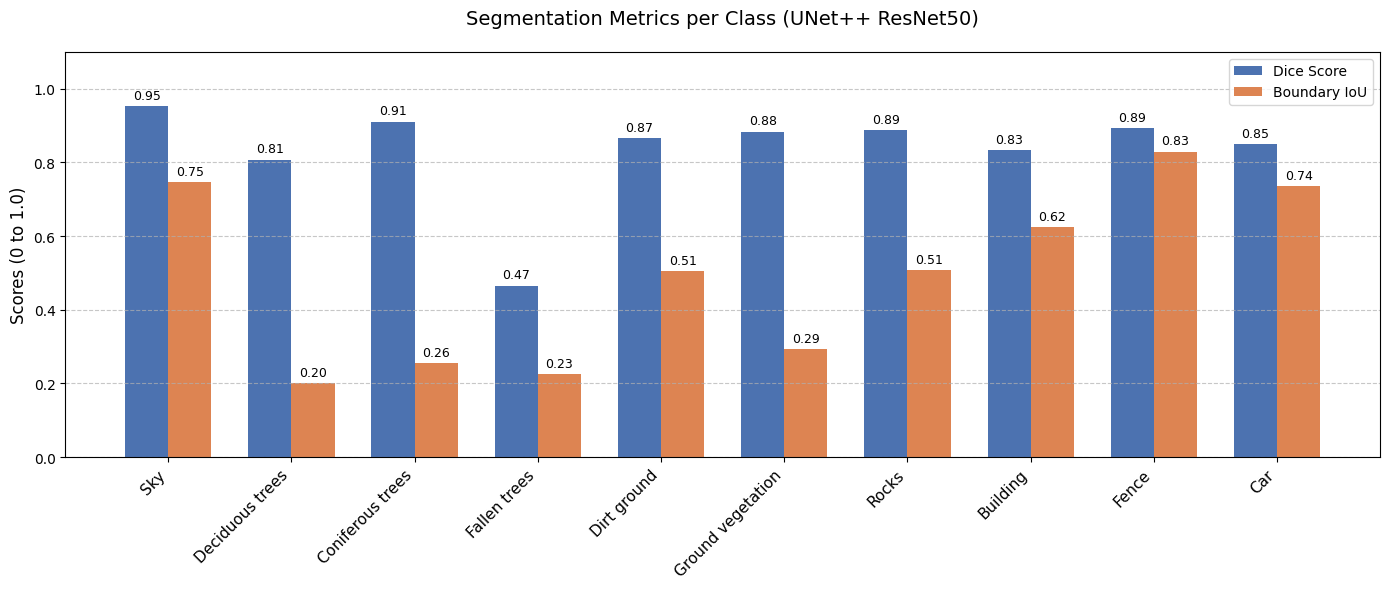

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. HÀM CHUYỂN ĐỔI ONE-HOT
# ==========================================
def to_one_hot(mask, num_classes):
    """
    Chuyển đổi mask từ dạng (B, H, W) sang dạng One-hot encoding (B, C, H, W).
    """
    if mask.dim() == 4 and mask.shape[1] == 1:
        mask = mask.squeeze(1)
        
    one_hot = F.one_hot(mask.long(), num_classes=num_classes)
    return one_hot.permute(0, 3, 1, 2).float()

# ==========================================
# 2. HÀM TÍNH METRICS CHO TỪNG CLASS
# ==========================================
def calculate_metrics_multiclass_per_class(pred_logits, target, num_classes, smooth=1e-6):
    """
    Tính Dice (F1) và Boundary IoU trả về mảng điểm của từng class trong 1 batch.
    """
    pred_mask = torch.argmax(pred_logits, dim=1) # (B, H, W)
    
    pred_one_hot = to_one_hot(pred_mask, num_classes)
    target_one_hot = to_one_hot(target, num_classes)
    
    # --- TÍNH DICE SCORE ---
    inter = (pred_one_hot * target_one_hot).sum(dim=(2, 3)) 
    union = pred_one_hot.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    dice_per_class = (2. * inter + smooth) / (union + smooth) # (B, C)
    
    # --- TÍNH BOUNDARY IOU ---
    kernel_size = 3
    pad = kernel_size // 2
    kernel = torch.ones((num_classes, 1, kernel_size, kernel_size), device=pred_logits.device)
    
    # Erosion cho prediction
    eroded_pred = F.conv2d(pred_one_hot, kernel, padding=pad, groups=num_classes)
    eroded_pred = (eroded_pred == kernel_size * kernel_size).float()
    pred_boundary = pred_one_hot - eroded_pred
    
    # Erosion cho target
    eroded_target = F.conv2d(target_one_hot, kernel, padding=pad, groups=num_classes)
    eroded_target = (eroded_target == kernel_size * kernel_size).float()
    target_boundary = target_one_hot - eroded_target
    
    # Boundary IoU
    b_inter = (pred_boundary * target_boundary).sum(dim=(2, 3))
    b_union = pred_boundary.sum(dim=(2, 3)) + target_boundary.sum(dim=(2, 3)) - b_inter
    biou_per_class = (b_inter + smooth) / (b_union + smooth)
    
    # Trả về trung bình của batch đó cho từng class -> Mảng (num_classes,)
    return dice_per_class.mean(dim=0), biou_per_class.mean(dim=0)

# ==========================================
# 3. HÀM ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
def evaluate_model_and_plot(model, dataloader, num_classes, class_names=None, device="cuda"):
    model.eval()
    
    total_dice_classes = torch.zeros(num_classes, device=device)
    total_biou_classes = torch.zeros(num_classes, device=device)
    n_batches = 0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            preds = model(images)
            
            # Gọi hàm trả về mảng điểm cho từng class
            batch_dice_classes, batch_biou_classes = calculate_metrics_multiclass_per_class(preds, masks, num_classes)
            
            total_dice_classes += batch_dice_classes
            total_biou_classes += batch_biou_classes
            n_batches += 1
            
    # Tính trung bình toàn bộ test set
    final_dice_classes = (total_dice_classes / n_batches).cpu().numpy()
    final_biou_classes = (total_biou_classes / n_batches).cpu().numpy()
    
    # Tự động tạo tên class nếu chưa cung cấp
    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
        
    # --- IN RA CONSOLE ---
    print(f"{'Class Name':<15} | {'Dice / F1':<10} | {'Boundary IoU':<10}")
    print("-" * 45)
    for i in range(num_classes):
        print(f"{class_names[i]:<15} | {final_dice_classes[i]:.4f}     | {final_biou_classes[i]:.4f}")
    print("-" * 45)
    print(f"{'AVERAGE (All)':<15} | {final_dice_classes.mean():.4f}     | {final_biou_classes.mean():.4f}")
    
    # Trung bình bỏ qua Background (mặc định Background là class 0)
    print(f"{'AVERAGE (No BG)':<15} | {final_dice_classes[1:].mean():.4f}     | {final_biou_classes[1:].mean():.4f}")

    # --- VẼ BIỂU ĐỒ ---
    x = np.arange(num_classes)
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    
    rects1 = ax.bar(x - width/2, final_dice_classes, width, label='Dice Score', color='#4C72B0')
    rects2 = ax.bar(x + width/2, final_biou_classes, width, label='Boundary IoU', color='#DD8452')

    ax.set_ylabel('Scores (0 to 1.0)', fontsize=12)
    ax.set_title('Segmentation Metrics per Class (UNet++ ResNet50)', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.1) # Dư 0.1 để số trên đầu cột không bị che

    # In giá trị lên đầu mỗi cột
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_per_class.png', dpi=300, bbox_inches='tight') 
    plt.show()

# ==========================================
# 4. THỰC THI (CHẠY ĐÁNH GIÁ)
# ==========================================

my_class_names = [
    "Sky",
    "Deciduous trees",
    "Coniferous trees",
    "Fallen trees",
    "Dirt ground",
    "Ground vegetation",
    "Rocks",
    "Building",
    "Fence",
    "Car"
]

NUM_CLASSES = 10 

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

evaluate_model_and_plot(
    model=model, 
    dataloader=test_loader, 
    num_classes=NUM_CLASSES, 
    class_names=my_class_names, 
    device=device
)

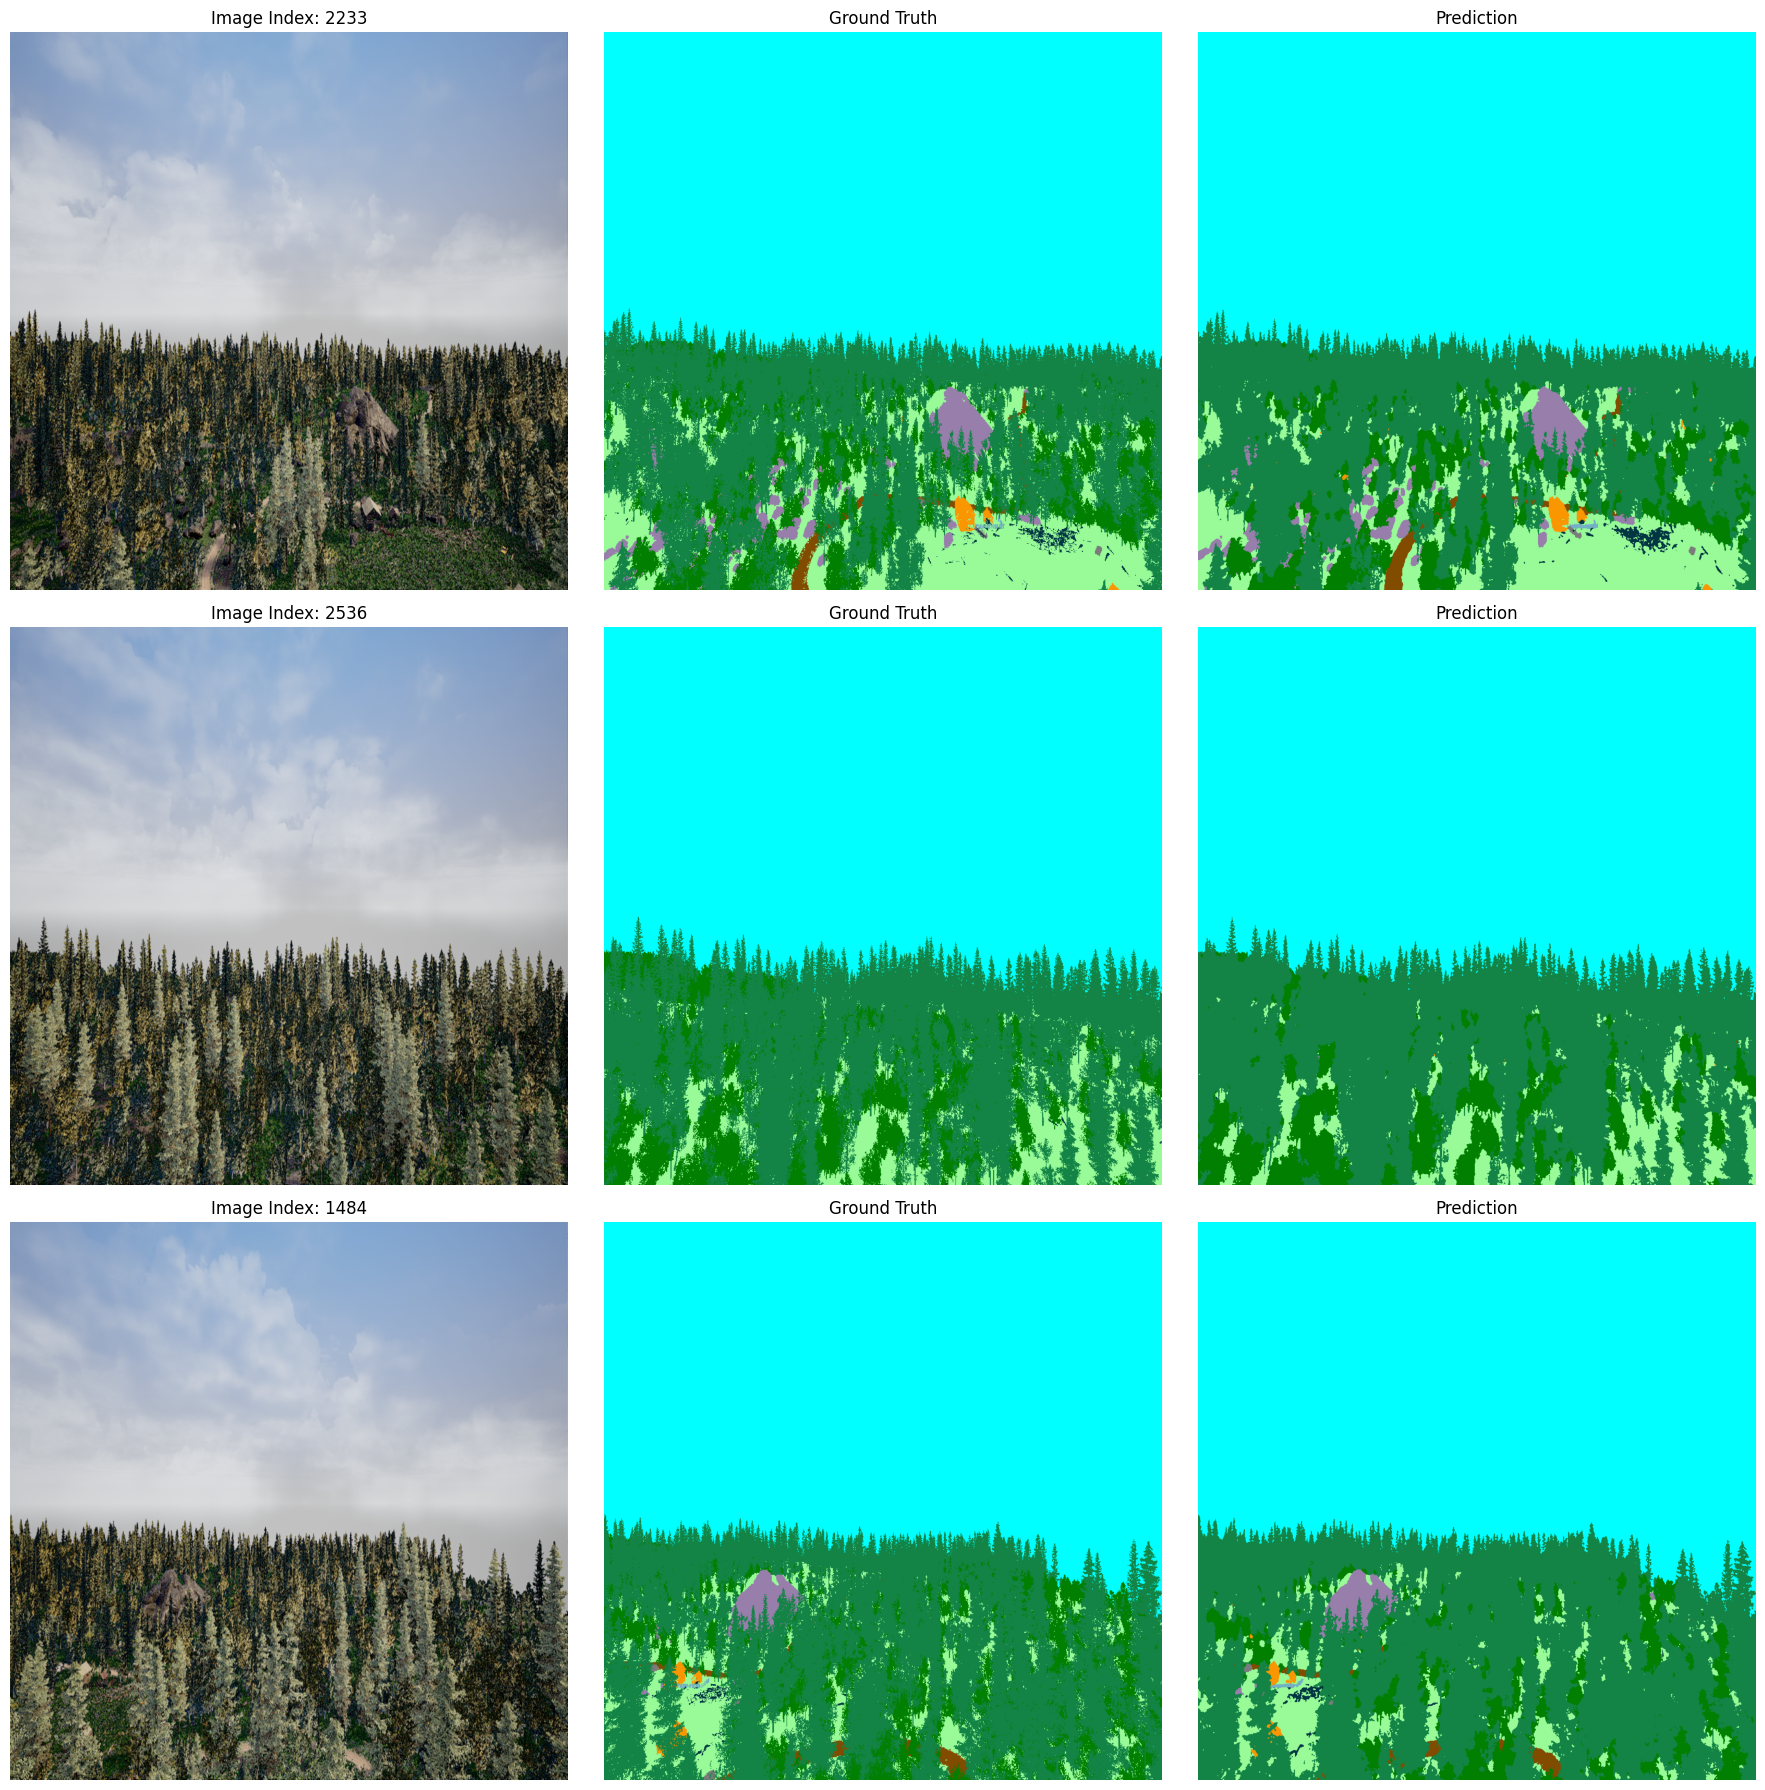

In [20]:
def visualize_predictions(dataset, model, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    plt.figure(figsize=(18, 6 * num_samples))
    
    for i, idx in enumerate(indices):
        img_tensor, mask_id = dataset[idx]
        
        # Inference
        with torch.no_grad():
            input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
            out = model(input_tensor)
            pred_id = out.argmax(1).squeeze(0).cpu().numpy()
            
        # Chuyển đổi về RGB để hiển thị
        img_show = img_tensor.permute(1, 2, 0).numpy()
        # Un-normalize ảnh để hiển thị đúng màu
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)
        
        gt_rgb = class_id_to_rgb_fast(mask_id.numpy())
        pred_rgb = class_id_to_rgb_fast(pred_id)
        
        # Vẽ đồ thị
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_show)
        plt.title(f"Image Index: {idx}")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_rgb)
        plt.title("Prediction")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Chạy thử hiển thị 3 mẫu ngẫu nhiên từ tập Test
visualize_predictions(test_ds, model, num_samples=3)


🔍 PHÂN TÍCH LỖI CÁC OBJECT NHỎ

  [3] Fallen_trees
    GT pixels   : 13,574,815
    IoU         : 0.6494
    Recall      : 0.8525  (bỏ sót 14.8% GT pixels)
    Precision   : 0.7316
    Nhầm thành  :
      → Ground_vegetation     : 1,301,474 px (9.6%)
      → Coniferous_trees      :  320,276 px (2.4%)
      → Deciduous_trees       :  313,693 px (2.3%)

  [8] Fence
    GT pixels   :    220,214
    IoU         : 0.6193
    Recall      : 0.8124  (bỏ sót 18.8% GT pixels)
    Precision   : 0.7226
    Nhầm thành  :
      → Ground_vegetation     :   30,956 px (14.1%)
      → Coniferous_trees      :    4,048 px (1.8%)
      → Building              :    2,612 px (1.2%)

  [9] Car
    GT pixels   :  1,042,534
    IoU         : 0.8419
    Recall      : 0.9259  (bỏ sót 7.4% GT pixels)
    Precision   : 0.9027
    Nhầm thành  :
      → Ground_vegetation     :   29,540 px (2.8%)
      → Coniferous_trees      :   19,700 px (1.9%)
      → Fallen_trees          :   11,580 px (1.1%)

  [7] Building
    

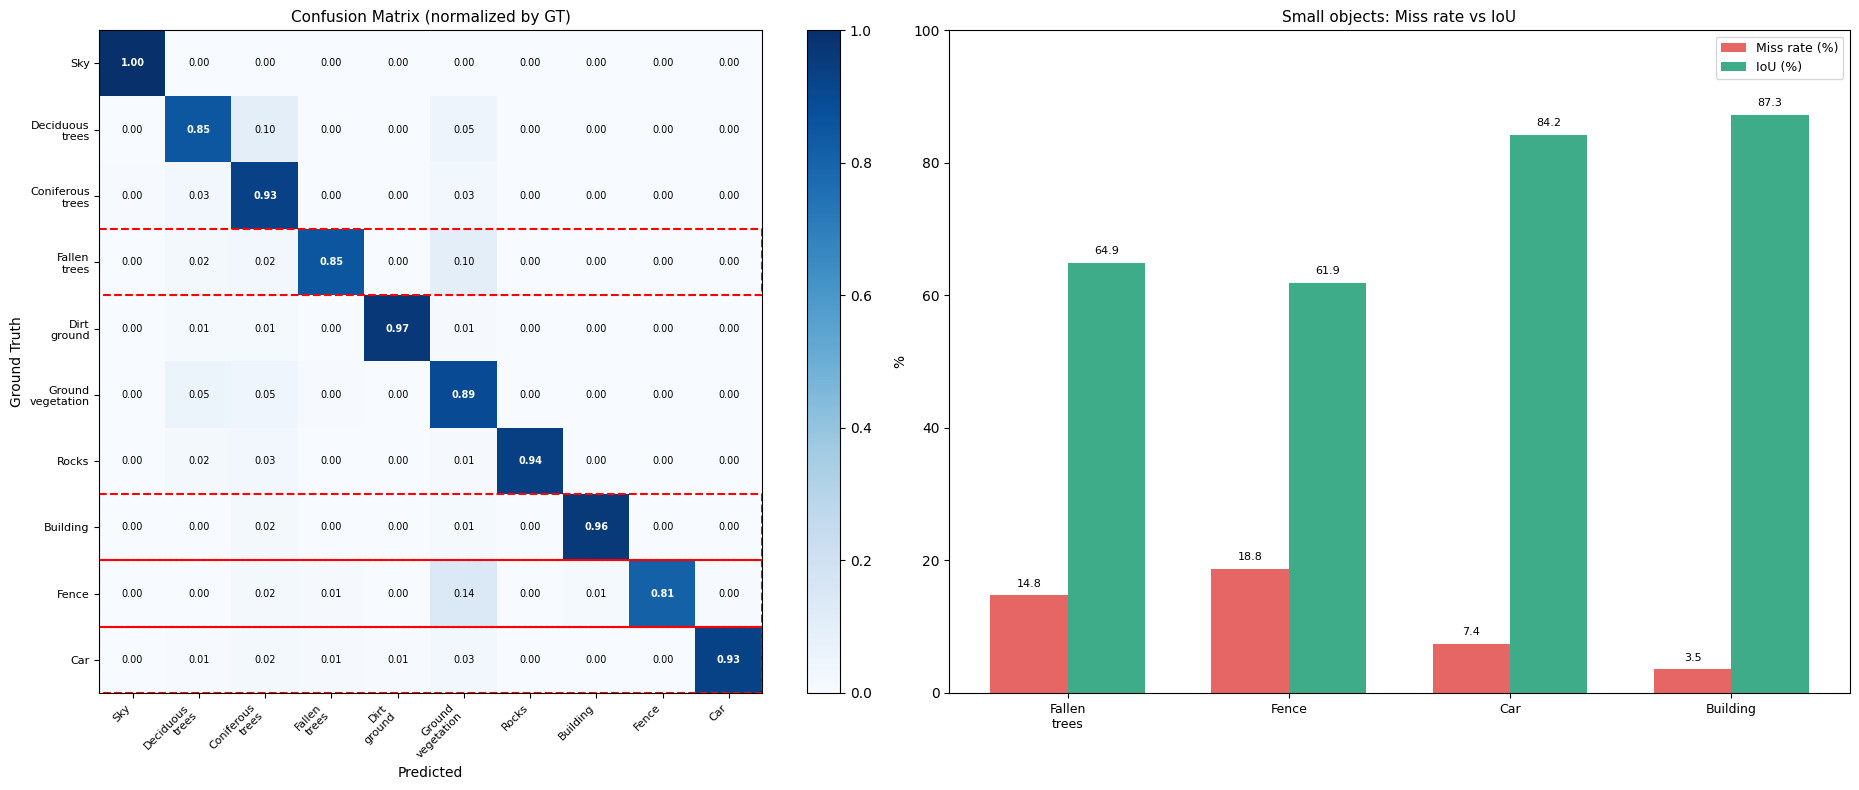

In [21]:
# Phân tích: model thường bị lỗi gì với các object nhỏ?
# Cụ thể: Fallen_trees (3), Fence (8), Car (9), Building (7)
# Các loại lỗi:
#   - Missed: GT có object nhỏ nhưng model bỏ sót hoàn toàn
#   - Confused: model nhầm object nhỏ thành class nào khác
#   - False positive: model predict có object nhỏ ở chỗ không có
SMALL_CLASSES = {
    3: 'Fallen_trees',
    8: 'Fence',
    9: 'Car',
    7: 'Building'
}


def analyze_small_object_errors(cm, class_names, small_class_ids, save_dir=None):
    """
    Phân tích lỗi chi tiết cho các class nhỏ/hiếm.
    In ra:
      1. Recall (Missed detection rate)
      2. Precision (False positive rate)  
      3. Top-3 class bị nhầm nhiều nhất
      4. Heatmap confusion matrix
    """
    n = len(class_names) - 1  # bỏ Empty

    inter     = np.diag(cm)
    row_sum   = cm.sum(axis=1)  # GT pixels per class
    col_sum   = cm.sum(axis=0)  # Predicted pixels per class

    print("\n" + "="*70)
    print("🔍 PHÂN TÍCH LỖI CÁC OBJECT NHỎ")
    print("="*70)

    error_summary = {}
    for cid in small_class_ids:
        name       = class_names[cid]
        tp         = cm[cid, cid]
        fn         = row_sum[cid] - tp          # GT có, predict sai
        fp         = col_sum[cid] - tp          # Predict có, GT không có
        total_gt   = row_sum[cid]
        recall     = tp / total_gt if total_gt > 0 else 0
        precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
        iou        = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        miss_rate  = fn / total_gt if total_gt > 0 else 0  # tỷ lệ bỏ sót

        # Top 3 class bị nhầm (bỏ qua chính class đó và Empty)
        confusion_row = cm[cid].copy()
        confusion_row[cid] = 0              # bỏ TP
        confusion_row[-1]  = 0              # bỏ Empty
        top3_confused = np.argsort(confusion_row)[::-1][:3]

        print(f"\n  [{cid}] {name}")
        print(f"    GT pixels   : {total_gt:>10,}")
        print(f"    IoU         : {iou:.4f}")
        print(f"    Recall      : {recall:.4f}  (bỏ sót {miss_rate*100:.1f}% GT pixels)")
        print(f"    Precision   : {precision:.4f}")
        print(f"    Nhầm thành  :")
        for j in top3_confused:
            n_confused = confusion_row[j]
            if n_confused > 0:
                pct = n_confused / total_gt * 100 if total_gt > 0 else 0
                print(f"      → {class_names[j]:<22}: {n_confused:>8,} px ({pct:.1f}%)")

        error_summary[name] = {
            'iou': iou, 'recall': recall, 'precision': precision,
            'miss_rate': miss_rate, 'total_gt_px': int(total_gt),
            'top_confusion': [(class_names[j], int(confusion_row[j]))
                              for j in top3_confused if confusion_row[j] > 0]
        }

    # ── CONFUSION MATRIX HEATMAP (normalized) ──────────────
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot 1: Full confusion matrix
    cm_norm = cm[:n, :n].astype(float)
    row_s   = cm_norm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_s > 0, cm_norm / row_s, 0)

    im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_xticks(range(n))
    axes[0].set_yticks(range(n))
    axes[0].set_xticklabels([c.replace('_', '\n') for c in class_names[:n]],
                             fontsize=8, rotation=45, ha='right')
    axes[0].set_yticklabels([c.replace('_', '\n') for c in class_names[:n]], fontsize=8)
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('Ground Truth', fontsize=10)
    axes[0].set_title('Confusion Matrix (normalized by GT)', fontsize=11)
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            color = 'white' if val > 0.5 else 'black'
            weight = 'bold' if i == j else 'normal'
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=7, color=color, fontweight=weight)

    # Highlight các small classes bằng khung đỏ
    for cid in small_class_ids:
        if cid < n:
            axes[0].add_patch(plt.Rectangle(
                (-0.5, cid - 0.5), n, 1,
                fill=False, edgecolor='red', linewidth=1.5, linestyle='--'))

    # Plot 2: Miss rate của small objects
    small_ids_valid = [c for c in small_class_ids if c < n]
    names_s    = [class_names[c] for c in small_ids_valid]
    miss_rates = [error_summary[class_names[c]]['miss_rate'] * 100
                  for c in small_ids_valid]
    ious_s     = [error_summary[class_names[c]]['iou'] * 100
                  for c in small_ids_valid]

    x = np.arange(len(names_s))
    w = 0.35
    bars1 = axes[1].bar(x - w/2, miss_rates, w, label='Miss rate (%)',
                        color='#E24B4A', alpha=0.85)
    bars2 = axes[1].bar(x + w/2, ious_s,    w, label='IoU (%)',
                        color='#1D9E75', alpha=0.85)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels([n.replace('_', '\n') for n in names_s], fontsize=9)
    axes[1].set_ylabel('%', fontsize=10)
    axes[1].set_title('Small objects: Miss rate vs IoU', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 100)

    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                         f'{h:.1f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                         f'{h:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    if save_dir:
        path = Path(save_dir) / 'small_object_error_analysis.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Saved: {path}")
    plt.show()

    return error_summary

# Chạy phân tích
small_class_ids = list(SMALL_CLASSES.keys())  # [3, 7, 8, 9]
error_summary = analyze_small_object_errors(
    cm_test, CLASS_NAMES, small_class_ids,
    save_dir=OUTPUT_DIR
)

In [22]:
import shutil
import os
from IPython.display import FileLink

# 1. Định nghĩa các đường dẫn
output_dir = '/kaggle/working/outputs'
log_dir = '/kaggle/working/outputs/logs'
# Thư mục chứa các file zip tải về
export_zip_path = '/kaggle/working/final_training_results'

# 2. Tạo một thư mục tạm để gom các file nhẹ (logs, txt, csv)
# Chúng ta sẽ không gom thư mục 'checkpoints' vì nó rất nặng và bạn đã tải rồi
temp_export_dir = '/kaggle/working/temp_results_for_report'
if os.path.exists(temp_export_dir):
    shutil.rmtree(temp_export_dir)
os.makedirs(temp_export_dir)

# Copy thư mục logs vào thư mục tạm
if os.path.exists(log_dir):
    shutil.copytree(log_dir, os.path.join(temp_export_dir, 'logs'))
    print("✅ Đã gom thư mục Logs.")

# Quét và copy các file văn bản (.txt, .csv, .json) trong thư mục output nếu có
for root, dirs, files in os.walk(output_dir):
    if 'checkpoints' in root: continue # Bỏ qua thư mục checkpoints
    for file in files:
        if file.endswith(('.txt', '.csv', '.json', '.png')):
            src_path = os.path.join(root, file)
            shutil.copy(src_path, temp_export_dir)

# 3. Nén tất cả lại thành file ZIP
shutil.make_archive(export_zip_path, 'zip', temp_export_dir)

print("-" * 50)
print(f"🎉 Đã nén xong toàn bộ kết quả báo cáo!")
print(f"📁 File: {export_zip_path}.zip")
print("-" * 50)

# 4. Hiển thị link tải
display(FileLink('final_training_results.zip'))

--------------------------------------------------
🎉 Đã nén xong toàn bộ kết quả báo cáo!
📁 File: /kaggle/working/final_training_results.zip
--------------------------------------------------


/kaggle/working/final_training_results.zip